In [31]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn.datasets as datasets
from sklearn.model_selection import train_test_split
import pandas as pd
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np



print (np.__version__) #2.3.3
print (train_test_split.__module__.split('.')[0] + " " + train_test_split.__module__.split('.')[1])

2.3.3
sklearn model_selection


In [32]:
columns_new = [
    'user_id', 'age', 'gender', 'occupation', 'work_mode', 'screen_time_hours', 
    'work_screen_hours', 'leisure_screen_hours', 'sleep_hours', 'sleep_quality_1_5', 
    'stress_level_0_10', 'productivity_0_100', 'exercise_minutes_per_week', 
    'social_hours_per_week', 'mental_wellness_index_0_100'
]

df = pd.read_csv('DataSets/ScreenTime vs MentalWellness.csv', usecols=columns_new)

In [33]:
df = df.drop(columns=['Unnamed: 15'], errors='ignore')

In [34]:
# Check column names
print("Columns in the dataset:")
print(df.columns.tolist())

# Strip extra spaces from column names
df.columns = df.columns.str.strip()

# Rename columns if necessary
if ' Age ' in df.columns:
    df.rename(columns={' Age ': 'Age'}, inplace=True)

# Verify if 'Age' exists


Columns in the dataset:
['user_id', 'age', 'gender', 'occupation', 'work_mode', 'screen_time_hours', 'work_screen_hours', 'leisure_screen_hours', 'sleep_hours', 'sleep_quality_1_5', 'stress_level_0_10', 'productivity_0_100', 'exercise_minutes_per_week', 'social_hours_per_week', 'mental_wellness_index_0_100']


In [35]:
df.sample(10)

,user_id,age,gender,occupation,work_mode,screen_time_hours,work_screen_hours,leisure_screen_hours,sleep_hours,sleep_quality_1_5,stress_level_0_10,productivity_0_100,exercise_minutes_per_week,social_hours_per_week,mental_wellness_index_0_100
317,U0318,27,Male,Self-employed,Hybrid,7.77,0.39,7.38,8.13,2,6.3,72.7,208,0.0,41.2
54,U0055,38,Female,Employed,Remote,9.47,2.40,7.07,8.22,2,7.2,60.0,77,10.2,34.4
307,U0308,25,Female,Student,In-person,10.44,1.87,8.57,4.64,1,7.1,52.2,94,5.5,9.4
287,U0288,34,Male,Employed,Hybrid,12.73,2.63,10.10,6.47,1,10.0,30.5,97,0.0,6.4
106,U0107,45,Female,Student,Remote,11.10,4.95,6.15,6.14,1,9.5,36.1,177,4.6,8.8
233,U0234,24,Male,Student,In-person,7.26,0.96,6.30,6.86,1,9.9,58.8,198,3.1,13.3
58,U0059,32,Male,Employed,Hybrid,11.49,1.10,10.39,7.10,2,7.2,67.8,15,0.0,29.9
216,U0217,23,Male,Employed,Hybrid,3.49,0.52,2.97,7.59,3,1.9,100.0,173,12.4,77.7
204,U0205,18,Female,Employed,Hybrid,10.68,0.88,9.80,7.08,1,10.0,50.1,241,3.1,6.2
51,U0052,26,Male,Student,Remote,10.25,5.59,4.66,6.33,1,10.0,38.5,181,5.4,0.3


In [36]:
categorical_columns = ['gender', 'occupation', 'work_mode']
numeric_columns = [
    'age', 'screen_time_hours', 'work_screen_hours', 'leisure_screen_hours', 
    'sleep_hours', 'sleep_quality_1_5', 'stress_level_0_10', 'productivity_0_100', 
    'exercise_minutes_per_week', 'social_hours_per_week'
]

In [37]:
X = df.drop(columns=['user_id', 'mental_wellness_index_0_100'])
y = df['mental_wellness_index_0_100']

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [39]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Define the preprocessor
processor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_columns),  # Scale numeric columns
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_columns)  # Encode categorical columns
    ]
)

In [40]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

# Define the pipeline
model = Pipeline(steps=[
    ('preprocessor', processor),  # Use the valid ColumnTransformer
    ('regressor', RandomForestRegressor(random_state=42))  # Random Forest Regressor
])

In [41]:
# Train the model
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [42]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Test R² Score: {r2:.4f}")
print(f"Test RMSE: {rmse:.4f}")

Test R² Score: 0.8909
Test RMSE: 6.5700


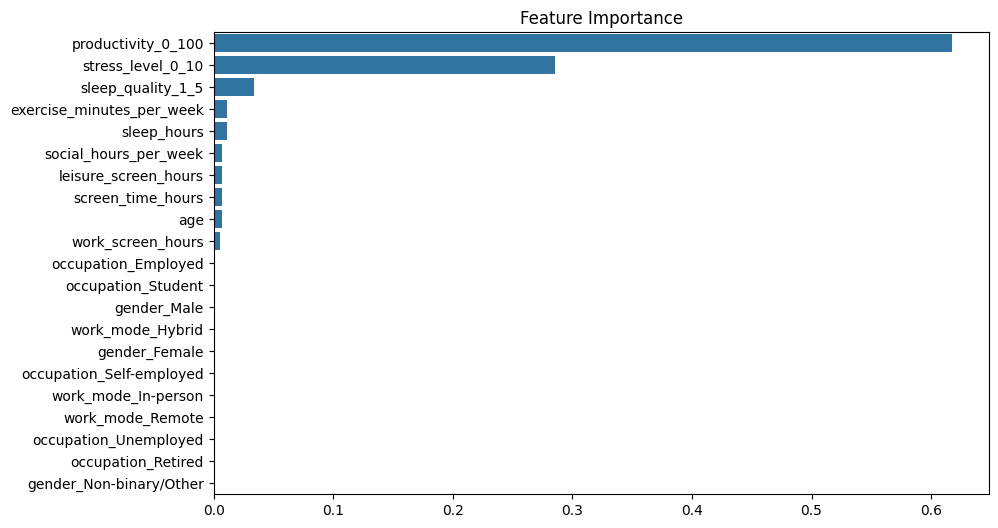

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract feature names after preprocessing
feature_names = numeric_columns + list(model.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out(categorical_columns))

# Get feature importances from the Random Forest model
feature_importances = model.named_steps['regressor'].feature_importances_

# Sort feature importances
sorted_indices = np.argsort(feature_importances)[::-1]

# Plot feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances[sorted_indices], y=np.array(feature_names)[sorted_indices])
plt.title("Feature Importance")
plt.show()

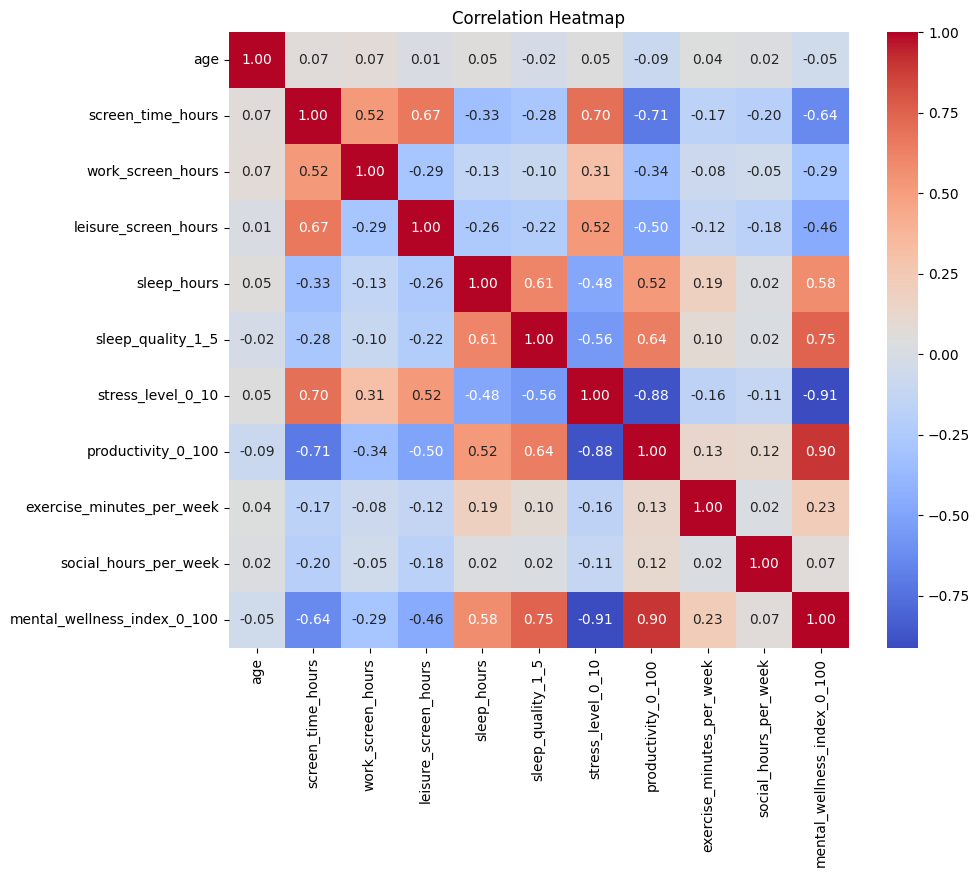

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns for correlation
numeric_columns = [
    'age', 'screen_time_hours', 'work_screen_hours', 'leisure_screen_hours', 
    'sleep_hours', 'sleep_quality_1_5', 'stress_level_0_10', 'productivity_0_100', 
    'exercise_minutes_per_week', 'social_hours_per_week', 'mental_wellness_index_0_100'
]

# Compute the correlation matrix
correlation_matrix = df[numeric_columns].corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title("Correlation Heatmap")
plt.show()